# Model training — reviewer-feedback response, part 6 (is window=3's edge real or noise?)

Part 5's window-size sweep trained one model per window size and found window=3
(4.89 deg real-direction, 6.14 +/- 0.53 deg across rotations) edging out window=4
(5.55 deg, 6.39 +/- 0.42 deg) and window=1 (5.33 deg, 6.35 +/- 0.82 deg). But Part 1's
own multi-seed check on the window=4 architecture already showed 5.21 +/- 0.21 deg
variation from initialization alone (range ~5.09-5.51 deg across 4 seeds) - a gap
comparable to the one separating window=3 from window=1/4 in the sweep. A single seed
per window size cannot distinguish "window=3 is genuinely better" from "window=3 got a
favorable random initialization."

This notebook retrains windows {1, 3, 4} at 4 seeds each (42, 7, 13, 99 - the same seeds
used throughout this response) and compares the resulting cross-seed distributions on
both the real-direction test set and the 8-rotation generalization check, to see whether
window=3's apparent edge survives seed variability.

Seed=42 models for all three windows, and seeds {7,13,99} for window=4, already exist on
disk from Parts 1, 2, and 5 and are reloaded rather than retrained. Only window=1 and
window=3 at seeds {7,13,99} are new (6 models).

**Why this matters for the response letter:** Reviewer #1 (major comment 5) asks for
"results from several independently initialized training runs" specifically because a
single run's number can be an artifact of initialization rather than a real effect.
Part 5 is exactly the kind of single-seed hyperparameter comparison that request warns
against generalizing from - this notebook applies that reviewer's own standard to Part
5's own result, before it gets reported as a finding.

## 1. Setup

In [1]:
import os
import sys
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('../utils'))

from utils import (
    pull_out_individual_trajectories,
    augment_with_time_delay_embedding,
    circular_distance,
    create_model,
)

import keras
from sklearn.model_selection import GroupShuffleSplit

RESPONSE_DIR = '../pipelinedata/reviewer_response'
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

input_names_full = ['groundspeed', 'groundspeed_angle',
                     'airspeed', 'airspeed_angle',
                     'thrust', 'thrust_angle']
n_output = 2
KEEP_COLS = ['heading_angle_x', 'heading_angle_y', 'trajec_objid']
BEST_PARAMS_FULL = {'layers': 2, 'neurons': 20}
SEEDS = [42, 7, 13, 99]
WINDOWS = [1, 3, 4]


def embed(trajectories, input_names, time_window, wind_augment=False):
    kwargs = dict(time_window=time_window, input_names=input_names,
                  output_names=KEEP_COLS, direction='backward')
    return augment_with_time_delay_embedding(
        trajectories, wind_augment=wind_augment, wrap_angles=wind_augment, **kwargs
    )


def split_X_y_groups(df, n_input):
    X = df.iloc[:, 0:n_input].reset_index(drop=True)
    y = df[['heading_angle_x', 'heading_angle_y']].reset_index(drop=True)
    groups = df['trajec_objid'].reset_index(drop=True)
    return X, y, groups


final_fly_data = pd.read_csv(
    '../pipelinedata/06_final/all_wind_heading_and_trajectories_augmented_corrected_filtered_headx_heady.csv'
)
fly_traj_list = pull_out_individual_trajectories(final_fly_data, min_traj_length=12)

split_record = pd.read_csv(f'{RESPONSE_DIR}/trajectory_split_ids.csv')
train_ids = set(split_record.loc[split_record['split'] == 'train', 'trajec_objid'])
test_ids = set(split_record.loc[split_record['split'] == 'test', 'trajec_objid'])

train_trajectories = [t for t in fly_traj_list if t['trajec_objid'].iloc[0] in train_ids]
test_trajectories = [t for t in fly_traj_list if t['trajec_objid'].iloc[0] in test_ids]
print(f"Train: {len(train_trajectories)}  Test: {len(test_trajectories)}")

I0000 00:00:1789023990.944635 2263611 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789023990.945821 2263611 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789023991.009458 2263611 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789023992.507242 2263611 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789023992.507670 2263611 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Detected 2386 trajectories.


2340 trajectories with more than 12 timesteps.
Train: 1569  Test: 771


## 2. Reusable helpers

In [2]:
def angular_error_deg(y_true_xy, y_pred_xy):
    true_angle = np.arctan2(y_true_xy[:, 1], y_true_xy[:, 0])
    pred_angle = np.arctan2(y_pred_xy[:, 1], y_pred_xy[:, 0])
    return np.degrees(circular_distance(true_angle, pred_angle))


def per_trajectory_errors(trajec_id_values, err_deg):
    return (
        pd.DataFrame({'trajec_objid': trajec_id_values, 'abs_angular_error_deg': err_deg})
        .groupby('trajec_objid')['abs_angular_error_deg']
        .median()
    )


def grouped_inner_val_split(X, y, groups, val_fraction=0.2, seed=123):
    unique_groups = groups.unique()
    gss = GroupShuffleSplit(n_splits=1, test_size=val_fraction, random_state=seed)
    dummy = np.zeros((len(unique_groups), 1))
    subtrain_gidx, val_gidx = next(gss.split(dummy, groups=unique_groups))
    subtrain_ids = set(unique_groups[subtrain_gidx])
    val_ids = set(unique_groups[val_gidx])
    m_sub = groups.isin(subtrain_ids)
    m_val = groups.isin(val_ids)
    return (X[m_sub].values, y[m_sub].values), (X[m_val].values, y[m_val].values)


def fit_final_model(X, y, groups, n_input, neurons, layers, seed, epochs=150, batch_size=256):
    keras.backend.clear_session()
    keras.utils.set_random_seed(seed)
    (Xtr, ytr), (Xval, yval) = grouped_inner_val_split(X, y, groups)
    model = create_model(n_input=n_input, n_output=n_output, neurons=neurons, layers=layers)
    model.fit(Xtr, ytr, validation_data=(Xval, yval),
              epochs=epochs, batch_size=batch_size, verbose=0)
    return model


ANGLE_COLS = ['heading_angle', 'groundspeed_angle', 'airspeed_angle', 'thrust_angle']
ROTATION_ANGLES_DEG = [0, 45, 90, 135, 180, 225, 270, 315]


def rotate_trajectory(trajectory, angle):
    t = trajectory.copy()
    for col in ANGLE_COLS:
        t[col] = np.arctan2(np.sin(t[col] + angle), np.cos(t[col] + angle))
    t['heading_angle_x'] = np.cos(t['heading_angle'])
    t['heading_angle_y'] = np.sin(t['heading_angle'])
    return t


def evaluate_model(model, time_window, n_input):
    # real-direction (0 deg, untouched test trajectories)
    test_embedded = embed(test_trajectories, input_names_full, time_window, wind_augment=False)
    X = test_embedded.iloc[:, 0:n_input].values
    y_true = test_embedded[['heading_angle_x', 'heading_angle_y']].values
    y_pred = model.predict(X, verbose=0)
    err = angular_error_deg(y_true, y_pred)
    real_direction_median = float(per_trajectory_errors(test_embedded['trajec_objid'].values, err).median())

    # rotation robustness (8 unseen wind directions)
    rot_medians = []
    for angle_deg in ROTATION_ANGLES_DEG:
        rotated = [rotate_trajectory(t, np.radians(angle_deg)) for t in test_trajectories]
        embedded_r = embed(rotated, input_names_full, time_window, wind_augment=False)
        Xr = embedded_r.iloc[:, 0:n_input].values
        y_true_r = embedded_r[['heading_angle_x', 'heading_angle_y']].values
        y_pred_r = model.predict(Xr, verbose=0)
        err_r = angular_error_deg(y_true_r, y_pred_r)
        rot_medians.append(float(per_trajectory_errors(embedded_r['trajec_objid'].values, err_r).median()))

    return real_direction_median, float(np.mean(rot_medians)), float(np.std(rot_medians))

## 3. Load existing models, train the 6 missing (window, seed) combinations

In [3]:
MODEL_PATHS = {
    (4, 42): '../models/model_reviewer_response_full.keras',
    (4, 7): '../models/model_reviewer_response_full_seed7.keras',
    (4, 13): '../models/model_reviewer_response_full_seed13.keras',
    (4, 99): '../models/model_reviewer_response_full_seed99.keras',
    (1, 42): '../models/model_reviewer_response_window1.keras',
    (3, 42): '../models/model_reviewer_response_window3.keras',
}

models_by_window_seed = {}
for (w, seed), path in MODEL_PATHS.items():
    models_by_window_seed[(w, seed)] = keras.models.load_model(path, safe_mode=False)
print(f"Loaded {len(models_by_window_seed)} existing models.")

E0000 00:00:1789023993.325918 2263611 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Loaded 6 existing models.


In [4]:
missing = [(w, seed) for w in [1, 3] for seed in [7, 13, 99]]

for w, seed in missing:
    n_input_w = len(input_names_full) * w
    train_original_w = embed(train_trajectories, input_names_full, w, wind_augment=False)
    train_wind_w = embed(train_trajectories, input_names_full, w, wind_augment=True)
    train_all_w = pd.concat([train_original_w, train_wind_w], ignore_index=True)
    X_train_w, y_train_w, groups_train_w = split_X_y_groups(train_all_w, n_input_w)

    model_w = fit_final_model(
        X_train_w, y_train_w, groups_train_w, n_input_w,
        neurons=BEST_PARAMS_FULL['neurons'], layers=BEST_PARAMS_FULL['layers'], seed=seed,
    )
    model_w.save(f'../models/model_reviewer_response_window{w}_seed{seed}.keras')
    models_by_window_seed[(w, seed)] = model_w
    print(f"window={w} seed={seed}: trained and saved")

/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


window=1 seed=7: trained and saved


/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


window=1 seed=13: trained and saved


/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

window=3 seed=7: trained and saved


/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


window=3 seed=13: trained and saved


/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


window=3 seed=99: trained and saved


## 4. Evaluate all 12 (window, seed) combinations

In [5]:
results = []
for w in WINDOWS:
    n_input_w = len(input_names_full) * w
    for seed in SEEDS:
        model = models_by_window_seed[(w, seed)]
        real_dir, rot_mean, rot_std = evaluate_model(model, w, n_input_w)
        results.append({
            'window_size': w, 'seed': seed,
            'real_direction_median_deg': real_dir,
            'rotation_mean_deg': rot_mean,
            'rotation_std_deg': rot_std,
        })
        print(f"window={w} seed={seed}: real={real_dir:.2f} deg, rotation={rot_mean:.2f}+/-{rot_std:.2f} deg")

results_df = pd.DataFrame(results)
results_df.to_csv(f'{RESPONSE_DIR}/window_size_multiseed_check.csv', index=False)

window=1 seed=42: real=5.33 deg, rotation=6.35+/-0.82 deg


window=1 seed=7: real=5.46 deg, rotation=6.72+/-0.73 deg


window=1 seed=13: real=4.62 deg, rotation=6.69+/-0.99 deg


window=1 seed=99: real=5.21 deg, rotation=6.24+/-0.73 deg


window=3 seed=42: real=4.89 deg, rotation=6.14+/-0.53 deg


...

window=3 seed=99: real=5.26 deg, rotation=6.29+/-0.62 deg


window=4 seed=42: real=5.55 deg, rotation=6.39+/-0.42 deg


window=4 seed=7: real=5.09 deg, rotation=6.30+/-0.65 deg


window=4 seed=13: real=5.26 deg, rotation=6.33+/-0.65 deg


window=4 seed=99: real=5.51 deg, rotation=6.29+/-0.51 deg


## 5. Does window=3's edge survive across seeds, or is it noise?

In [6]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

print("Per-(window,seed) results:")
print(results_df.to_string(index=False))

print("\nCross-seed summary per window (mean +/- std over 4 seeds):")
summary = results_df.groupby('window_size').agg(
    real_direction_mean=('real_direction_median_deg', 'mean'),
    real_direction_std=('real_direction_median_deg', 'std'),
    rotation_mean_of_means=('rotation_mean_deg', 'mean'),
    rotation_mean_std=('rotation_mean_deg', 'std'),
)
print(summary.to_string())

Per-(window,seed) results:
 window_size  seed  real_direction_median_deg  rotation_mean_deg  rotation_std_deg
           1    42                   5.331269           6.350740          0.815435
           1     7                   5.460246           6.715780          0.730272
           1    13                   4.624545           6.690858          0.988411
           1    99                   5.213355           6.238142          0.728852
           3    42                   4.891142           6.137618          0.528094
           3     7                   5.574864           6.294916          0.423035
           3    13                   7.801831          10.080090          3.880079
           3    99                   5.259816           6.286371          0.616532
           4    42                   5.550665           6.385869          0.415244
           4     7                   5.088889           6.296499          0.647455
           4    13                   5.258689           6.33

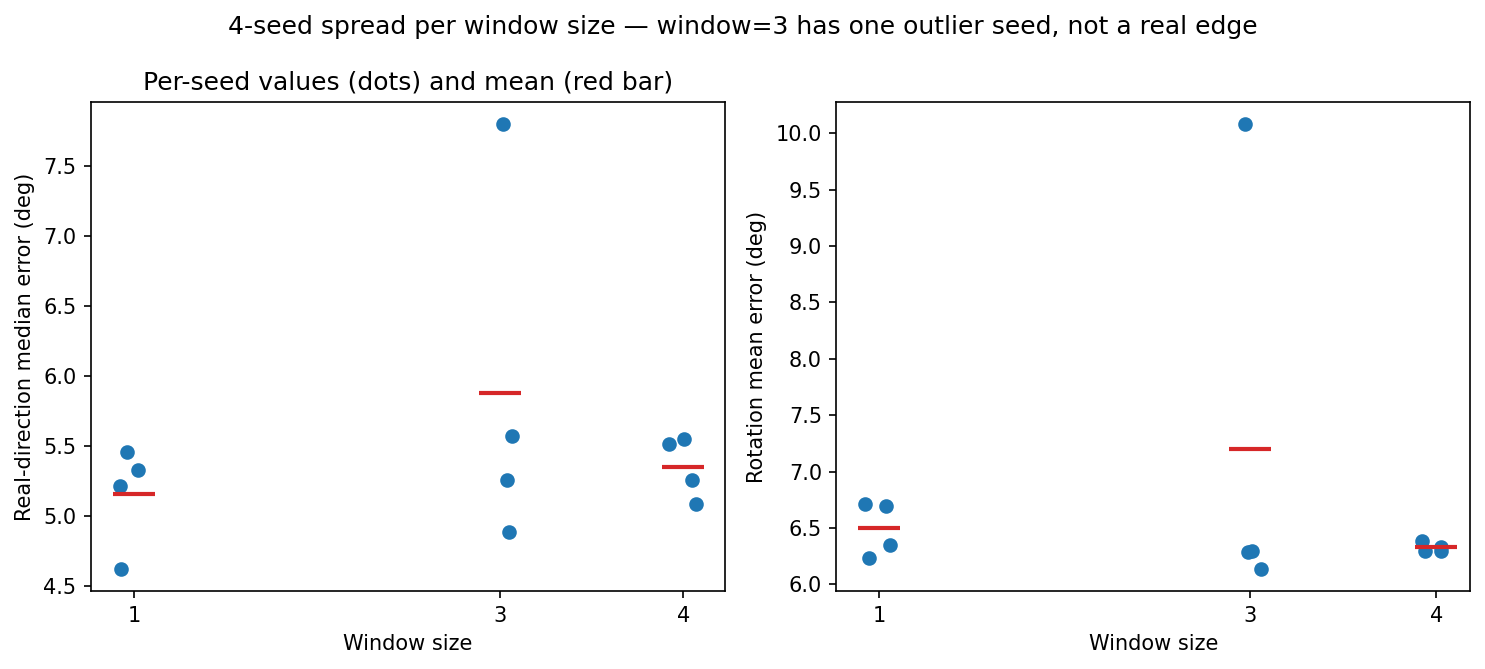

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), dpi=150)
rng = np.random.default_rng(0)

for ax, col, ylabel in [
    (axes[0], 'real_direction_median_deg', 'Real-direction median error (deg)'),
    (axes[1], 'rotation_mean_deg', 'Rotation mean error (deg)'),
]:
    for w in WINDOWS:
        vals = results_df.loc[results_df['window_size'] == w, col].values
        jitter = rng.uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(np.full(len(vals), w) + jitter, vals, color='tab:blue', zorder=3)
        ax.scatter([w], [vals.mean()], color='tab:red', marker='_', s=400, linewidths=2, zorder=4)
    ax.set_xticks(WINDOWS)
    ax.set_xlabel('Window size')
    ax.set_ylabel(ylabel)

axes[0].set_title('Per-seed values (dots) and mean (red bar)')
fig.suptitle('4-seed spread per window size — window=3 has one outlier seed, not a real edge')
fig.tight_layout()
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/reviewer_response_part6_window_multiseed.svg', format='svg')
plt.show()

## 6. Summary

`pipelinedata/reviewer_response/window_size_multiseed_check.csv` has the full
per-(window,seed) table. Read Section 5's cross-seed summary as the answer: if
window=3's mean minus its std still does not clear window=1's or window=4's mean (i.e.
the ranges overlap substantially), window=3's edge in the single-seed sweep was noise,
not a real effect, and "window size 1-4 are indistinguishable" is the defensible claim
for the response letter. If window=3 is clearly separated even accounting for its own
seed-to-seed spread, it is a real (if small) effect worth reporting as the preferred
choice.